In [7]:
import struct

def test_read_headers(file_path, num_entries=3):
    with open(file_path, 'rb') as f:
        for _ in range(num_entries):
            # 헤더 읽기 (13 bytes)
            header_data = f.read(13)
            if not header_data:
                break

            # C++ 코드의 reverse_bytes 동작을 고려한 빅 엔디언 처리
            header = {
                'label': struct.unpack('>B', header_data[0:1])[0],
                'data_index': struct.unpack('>H', header_data[1:3])[0],
                'unique_global_id': struct.unpack('>I', header_data[3:7])[0],
                'num_data_points': struct.unpack('>I', header_data[7:11])[0],
                'reserved1': struct.unpack('>B', header_data[11:12])[0],
                'reserved2': struct.unpack('>B', header_data[12:13])[0]
            }

            # 스파이크 데이터 건너뛰기 (C++ 코드의 seek 로직 반영)
            spike_block_size = header['num_data_points'] * 6  # 4(spike_time) + 2(neuron_index)
            f.seek(spike_block_size, 1)  # 현재 위치 기준 이동

            print(f"[Header {_+1}]")
            for k, v in header.items():
                print(f"  {k}: {v}")
            print("="*50)

# 테스트 실행
test_read_headers('/home/sungminlee/speakmin/tools/speech-to-spikes/gen_spike/0115_all_32_2_no_pre_norm/train0.bin')


[Header 1]
  label: 1
  data_index: 277
  unique_global_id: 4095
  num_data_points: 1908
  reserved1: 0
  reserved2: 0
[Header 2]
  label: 6
  data_index: 6
  unique_global_id: 26449
  num_data_points: 1243
  reserved1: 0
  reserved2: 0
[Header 3]
  label: 11
  data_index: 175
  unique_global_id: 48359
  num_data_points: 1956
  reserved1: 0
  reserved2: 0


In [10]:
def test_read_first_entries(file_path, num_entries=3, spikes_per_entry=5):
    with open(file_path, 'rb') as f:
        for entry_idx in range(num_entries):
            # 헤더 읽기
            header_data = f.read(13)
            header = {
                'label': struct.unpack('>B', header_data[0:1])[0],
                'num_data_points': struct.unpack('>I', header_data[7:11])[0]
            }

            # 스파이크 데이터 추출
            spikes = []
            for _ in range(header['num_data_points']):
                spike_time = struct.unpack('>I', f.read(4))[0]  # 4 bytes
                neuron_index = struct.unpack('>H', f.read(2))[0]  # 2 bytes
                spikes.append((spike_time, neuron_index))

            # 첫 5개 스파이크 출력
            print(f"Entry {entry_idx+1} (Label: {header['label']}, Spikes: {len(spikes)})")
            for i, (t, n) in enumerate(spikes[:spikes_per_entry]):
                print(f"  Spike {i+1}: Time={t}, Neuron={n}")
            print("="*50)

# 테스트 실행
test_read_first_entries('/home/sungminlee/speakmin/tools/speech-to-spikes/gen_spike/0115_all_32_2_no_pre_norm/train0.bin')


Entry 1 (Label: 1, Spikes: 1908)
  Spike 1: Time=375324, Neuron=4
  Spike 2: Time=377913, Neuron=7
  Spike 3: Time=378179, Neuron=6
  Spike 4: Time=378269, Neuron=4
  Spike 5: Time=378409, Neuron=3
Entry 2 (Label: 6, Spikes: 1243)
  Spike 1: Time=261653, Neuron=25
  Spike 2: Time=262701, Neuron=29
  Spike 3: Time=265434, Neuron=29
  Spike 4: Time=265879, Neuron=24
  Spike 5: Time=266388, Neuron=28
Entry 3 (Label: 11, Spikes: 1956)
  Spike 1: Time=307065, Neuron=3
  Spike 2: Time=313757, Neuron=2
  Spike 3: Time=316462, Neuron=3
  Spike 4: Time=324002, Neuron=2
  Spike 5: Time=324939, Neuron=3


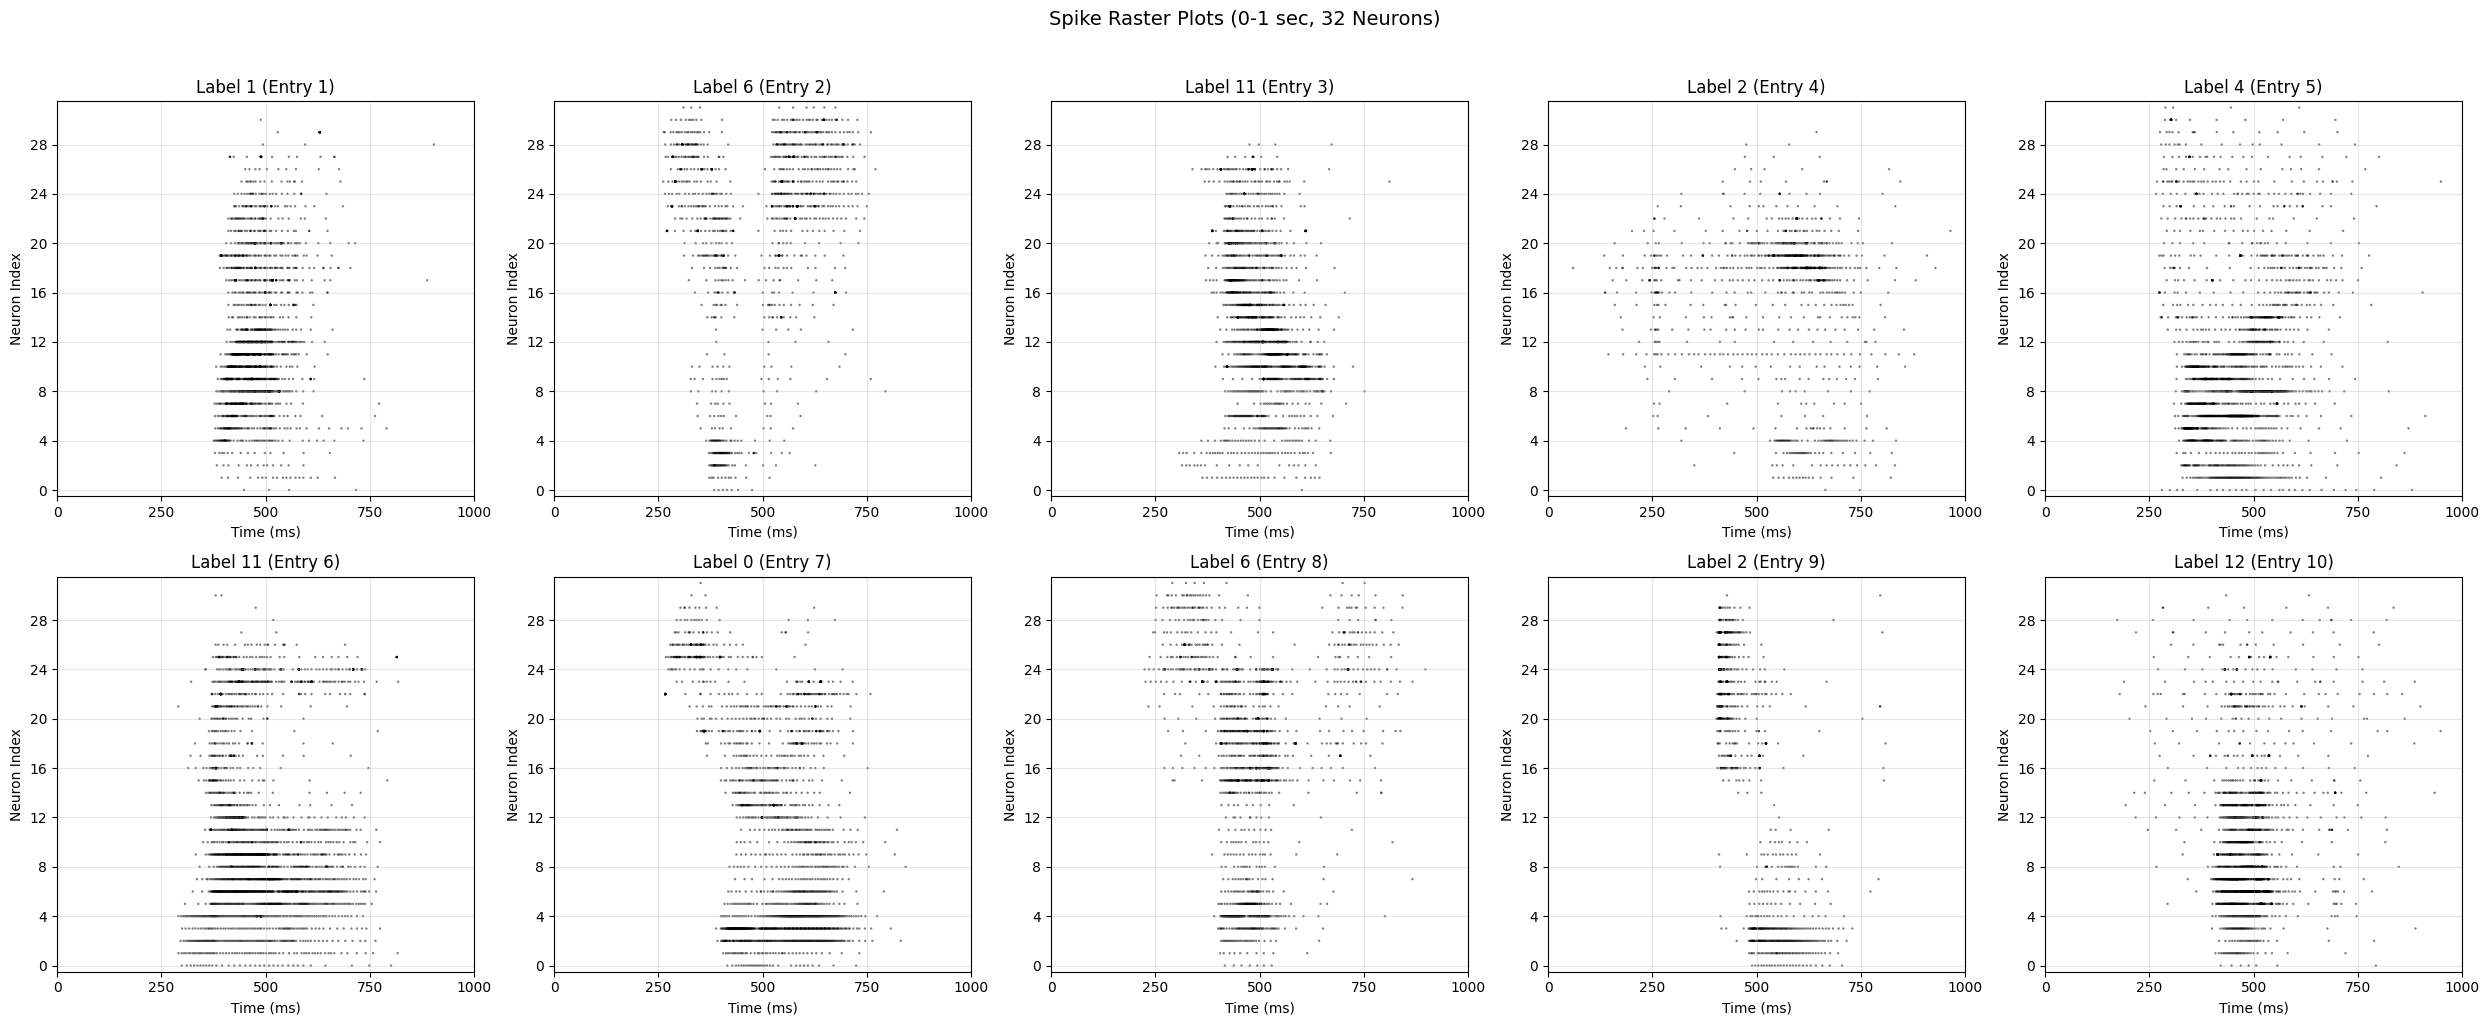

In [11]:
import struct
import matplotlib.pyplot as plt
import numpy as np

# Define binary format (big-endian)
data_format = [
    ('label', '>B', 1),
    ('data_index', '>H', 2),
    ('unique_global_id', '>I', 4),
    ('num_data_points', '>I', 4),
    ('reserved1', '>B', 1),
    ('reserved2', '>B', 1)
]

spike_format = [
    ('spike_time', '>I', 4),
    ('neuron_index', '>H', 2)
]

def read_entry(file):
    header_data = file.read(13)
    if not header_data:
        return None

    header = {}
    offset = 0
    for name, fmt, size in data_format:
        header[name] = struct.unpack(fmt, header_data[offset:offset+size])[0]
        offset += size

    spikes = []
    for _ in range(header['num_data_points']):
        spike_data = file.read(6)
        if len(spike_data) < 6:
            break
        spike = {
            'spike_time': struct.unpack('>I', spike_data[:4])[0],
            'neuron_index': struct.unpack('>H', spike_data[4:6])[0] & 0x1F  # 5비트 마스킹
        }
        spikes.append(spike)
    return header, spikes

# 파일 경로 설정
file_path = '/home/sungminlee/speakmin/tools/speech-to-spikes/gen_spike/0115_all_32_2_no_pre_norm/train0.bin'

# 첫 10개 엔트리 로드
entries = []
with open(file_path, 'rb') as f:
    for _ in range(10):
        entry = read_entry(f)
        if entry:
            entries.append(entry)

# 시각화 설정
fig, axes = plt.subplots(2, 5, figsize=(25, 10), dpi=100)
fig.suptitle('Spike Raster Plots (0-1 sec, 32 Neurons)', fontsize=14, y=1.02)

for idx, (header, spikes) in enumerate(entries):
    ax = axes[idx//5, idx%5]
    
    times = [s['spike_time']/1000 for s in spikes]  # μs → ms 변환
    neurons = [s['neuron_index'] for s in spikes]
    
    # 시각화 옵션
    ax.scatter(times, neurons, s=3, alpha=0.5, c='k', edgecolors='none')
    
    # 축 설정
    ax.set_xlim(0, 1000)  # 0-1000 ms
    ax.set_ylim(-0.5, 31.5)
    ax.set_xticks(np.linspace(0, 1000, 5))
    ax.set_yticks(np.arange(0, 32, 4))
    
    ax.set_title(f"Label {header['label']} (Entry {idx+1})")
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Neuron Index')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
import struct
import matplotlib.pyplot as plt

def validate_gscd_bin(file_path):
    with open(file_path, 'rb') as f:
        entry_count = 0
        while True:
            # 헤더 읽기 (13 bytes)
            header = f.read(13)
            if not header:
                break
                
            # C++ 포맷 검증: >B H I I B B
            label, data_index, uid, num_points, res1, res2 = struct.unpack('>B H I I B B', header)
            
            # 스파이크 데이터 읽기
            spikes = []
            for _ in range(num_points):
                spike_data = f.read(6)
                if len(spike_data) != 6:
                    raise ValueError(f"Corrupted spike data in entry {entry_count}")
                
                # C++ reverse_bytes 검증
                time = struct.unpack('>I', spike_data[:4])[0]
                neuron = struct.unpack('>H', spike_data[4:6])[0] & 0x1F
                
                spikes.append((time, neuron))
            
            # 결과 출력
            print(f"Entry {entry_count}:")
            print(f"  Label: {label}, Data Index: {data_index}")
            print(f"  UID: {uid}, Spikes: {len(spikes)}")
            print(f"  First spike: Time={spikes[0][0]} μs, Neuron={spikes[0][1]}")
            print(f"  Last spike: Time={spikes[-1][0]} μs, Neuron={spikes[-1][1]}")
            print("-" * 50)
            
            entry_count += 1

# 실행 예시
validate_gscd_bin('/home/sungminlee/speakmin/tools/speech-to-spikes/gen_spike/train0.bin')

'''
Entry 0:
  Label: 6, Data Index: 6
  UID: 26449, Spikes: 1162
  First spike: Time=178458 μs, Neuron=29
  Last spike: Time=192146 μs, Neuron=28
--------------------------------------------------
Entry 1:
  Label: 1, Data Index: 277
  UID: 4095, Spikes: 1157
  First spike: Time=177656 μs, Neuron=4
  Last spike: Time=185288 μs, Neuron=6
--------------------------------------------------
'''


Entry 0:
  Label: 6, Data Index: 6
  UID: 26449, Spikes: 1162
  First spike: Time=178458 μs, Neuron=29
  Last spike: Time=876196 μs, Neuron=27
--------------------------------------------------
Entry 1:
  Label: 1, Data Index: 277
  UID: 4095, Spikes: 1157
  First spike: Time=177656 μs, Neuron=4
  Last spike: Time=849919 μs, Neuron=19
--------------------------------------------------
Entry 2:
  Label: 4, Data Index: 158
  UID: 8419, Spikes: 1128
  First spike: Time=45568 μs, Neuron=25
  Last spike: Time=997945 μs, Neuron=9
--------------------------------------------------
Entry 3:
  Label: 0, Data Index: 108
  UID: 70601, Spikes: 1825
  First spike: Time=98726 μs, Neuron=26
  Last spike: Time=944256 μs, Neuron=21
--------------------------------------------------
Entry 4:
  Label: 6, Data Index: 26
  UID: 25734, Spikes: 1452
  First spike: Time=143015 μs, Neuron=24
  Last spike: Time=838981 μs, Neuron=23
--------------------------------------------------
Entry 5:
  Label: 11, Data In

'\nEntry 0:\n  Label: 6, Data Index: 6\n  UID: 26449, Spikes: 1162\n  First spike: Time=178458 μs, Neuron=29\n  Last spike: Time=192146 μs, Neuron=28\n--------------------------------------------------\nEntry 1:\n  Label: 1, Data Index: 277\n  UID: 4095, Spikes: 1157\n  First spike: Time=177656 μs, Neuron=4\n  Last spike: Time=185288 μs, Neuron=6\n--------------------------------------------------\n'

INFO:__main__:데이터 로드 시작...
INFO:__main__:총 6000개 엔트리 로드 완료
INFO:__main__:시각화 생성 중...


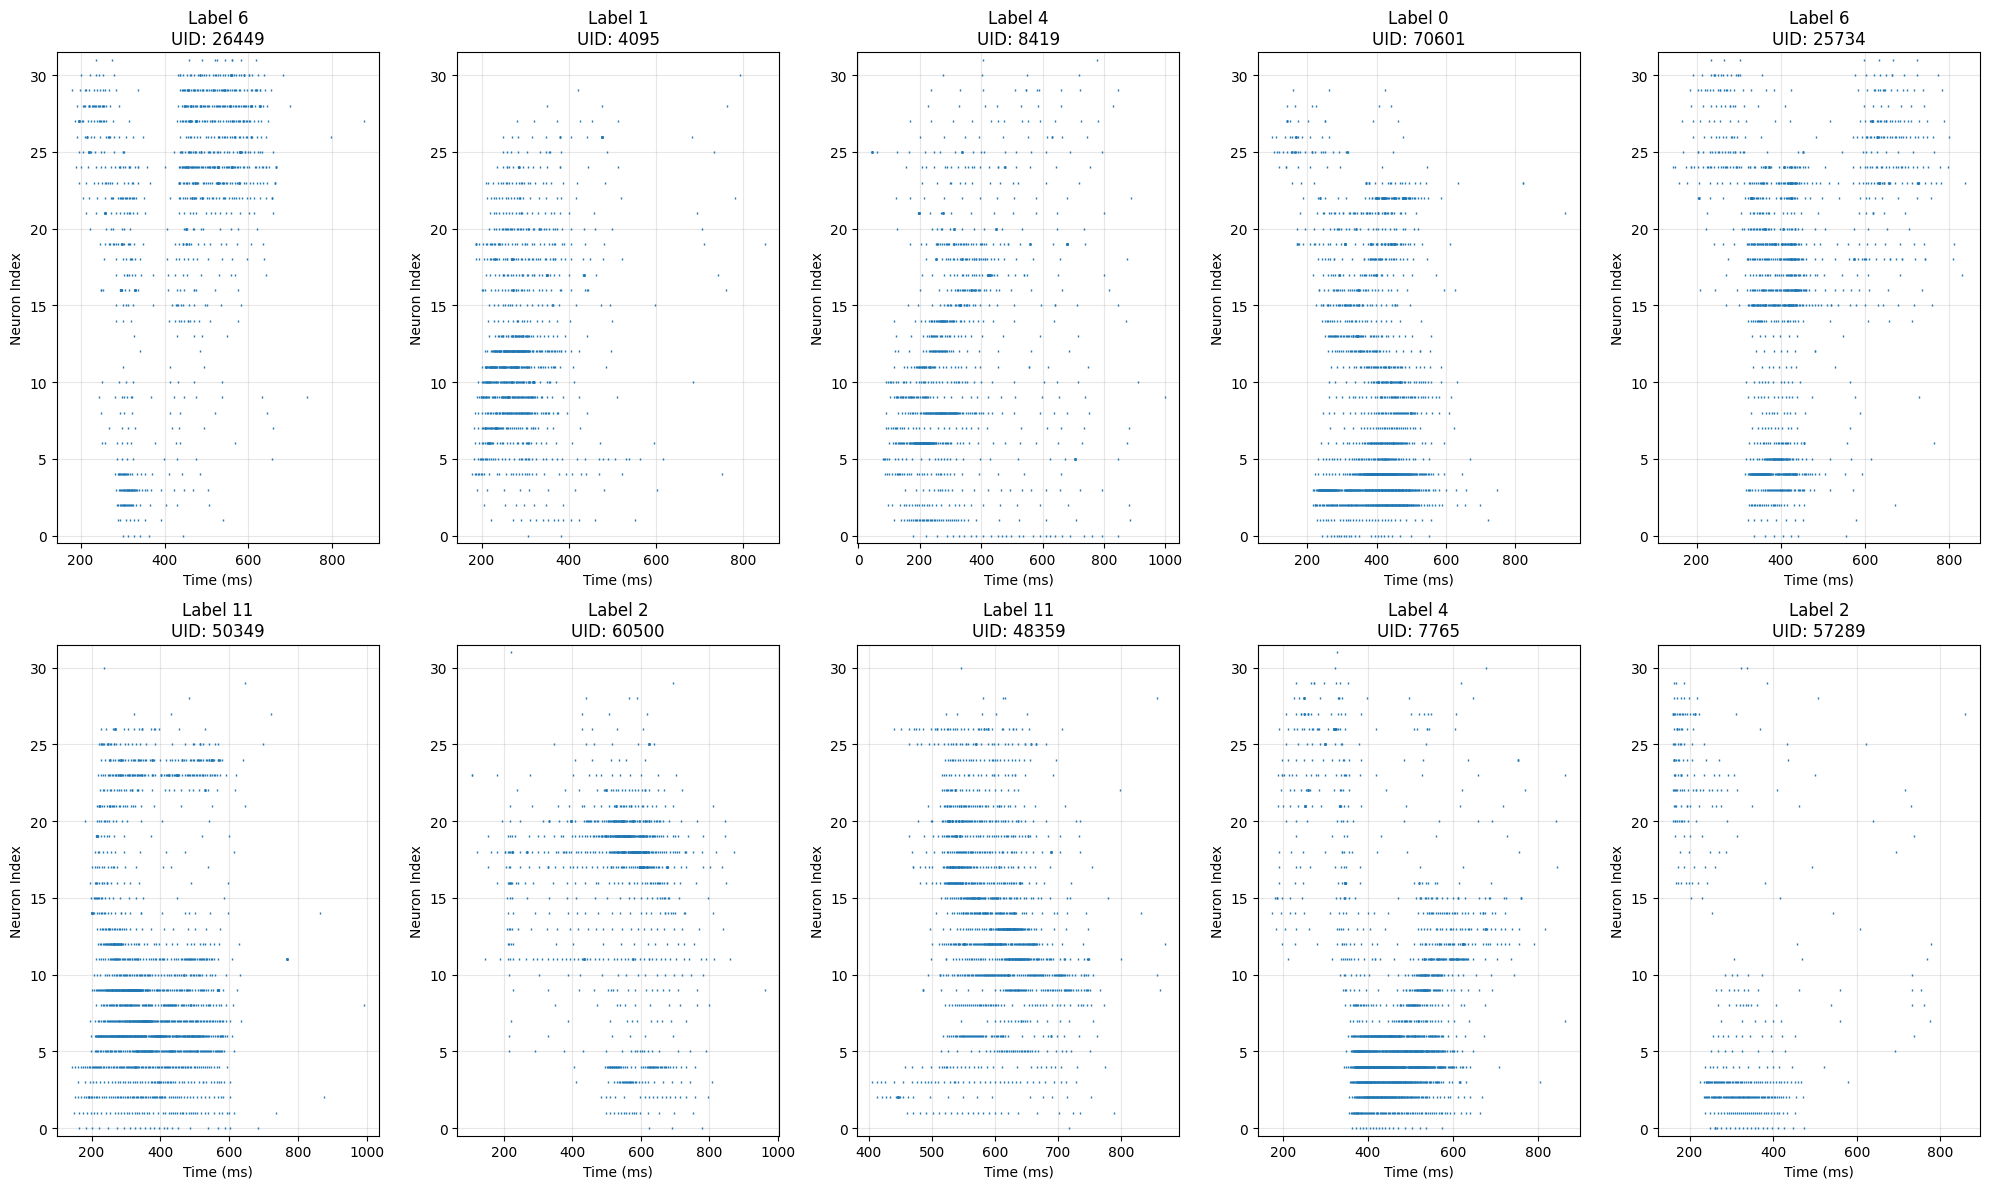

In [16]:
import struct
import matplotlib.pyplot as plt
import numpy as np
import logging

# 로깅 설정
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# 데이터 포맷 정의 (C++ reverse_bytes와 완전 일치)
DATA_FORMAT = [
    ('label', '>B', 1),        # 1바이트 (0-255)
    ('data_index', '>H', 2),   # 2바이트 (0-65535)
    ('unique_global_id', '>I', 4),
    ('num_data_points', '>I', 4),
    ('reserved1', '>B', 1),
    ('reserved2', '>B', 1)
]

SPIKE_FORMAT = [
    ('spike_time', '>I', 4),  # 4바이트 (0-1,000,000 μs)
    ('neuron_index', '>H', 2) # 2바이트 (하위 5비트만 사용)
]

def read_binary_data(file_path):
    """바이너리 파일 읽기 + 무결성 검증"""
    data = []
    with open(file_path, 'rb') as f:
        header_size = sum(size for _, _, size in DATA_FORMAT)
        spike_size = sum(size for _, _, size in SPIKE_FORMAT)
        
        entry_idx = 0
        while True:
            # 헤더 읽기
            header_data = f.read(header_size)
            if not header_data:
                break
            
            # 헤더 파싱
            header = {}
            offset = 0
            try:
                for name, fmt, size in DATA_FORMAT:
                    header[name] = struct.unpack(fmt, header_data[offset:offset+size])[0]
                    offset += size
            except struct.error as e:
                logger.error(f"Entry {entry_idx} 헤더 파싱 실패: {str(e)}")
                break
            
            # 스파이크 데이터 검증
            expected_spikes = header['num_data_points']
            spikes = []
            for _ in range(expected_spikes):
                spike_data = f.read(spike_size)
                if len(spike_data) != spike_size:
                    logger.warning(f"Entry {entry_idx} 스파이크 데이터 불완전")
                    break
                
                try:
                    spike_time = struct.unpack('>I', spike_data[:4])[0]
                    neuron_idx = struct.unpack('>H', spike_data[4:6])[0] & 0x1F  # 5비트 마스킹
                    
                    # 시간 범위 검증 (0-1,000,000 μs)
                    if not (0 <= spike_time <= 1_000_000):
                        logger.warning(f"Entry {entry_idx} 시간 범위 초과: {spike_time} μs")
                    
                    # 뉴런 인덱스 검증 (0-31)
                    if not (0 <= neuron_idx <= 31):
                        logger.warning(f"Entry {entry_idx} 잘못된 뉴런 인덱스: {neuron_idx}")
                        
                    spikes.append({
                        'spike_time': spike_time,
                        'neuron_index': neuron_idx
                    })
                except struct.error as e:
                    logger.error(f"Entry {entry_idx} 스파이크 파싱 실패: {str(e)}")
                    break
            
            # 실제 스파이크 수 검증
            if len(spikes) != expected_spikes:
                logger.error(f"Entry {entry_idx} 스파이크 수 불일치: 헤더={expected_spikes}, 실제={len(spikes)}")
            
            data.append((header, spikes))
            entry_idx += 1
    
    return data

def visualize_spikes(data, num_entries=10):
    """첫 N개 항목 시각화"""
    plt.figure(figsize=(20, 12))
    
    for idx in range(min(num_entries, len(data))):
        header, spikes = data[idx]
        times = [s['spike_time'] / 1000 for s in spikes]  # μs → ms 변환
        neurons = [s['neuron_index'] for s in spikes]
        
        plt.subplot(2, 5, idx+1)
        plt.plot(times, neurons, '|', markersize=2)
        plt.title(f"Label {header['label']}\nUID: {header['unique_global_id']}")
        plt.xlabel('Time (ms)')
        plt.ylabel('Neuron Index')
        plt.ylim(-0.5, 31.5)
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 테스트 실행
if __name__ == "__main__":
    # 파일 경로 설정
    file_path = "/home/sungminlee/speakmin/tools/speech-to-spikes/gen_spike/train0.bin"
    
    # 데이터 로드 및 검증
    logger.info("데이터 로드 시작...")
    dataset = read_binary_data(file_path)
    logger.info(f"총 {len(dataset)}개 엔트리 로드 완료")
    
    # 시각화
    if dataset:
        logger.info("시각화 생성 중...")
        visualize_spikes(dataset)
    else:
        logger.error("로드된 데이터 없음")


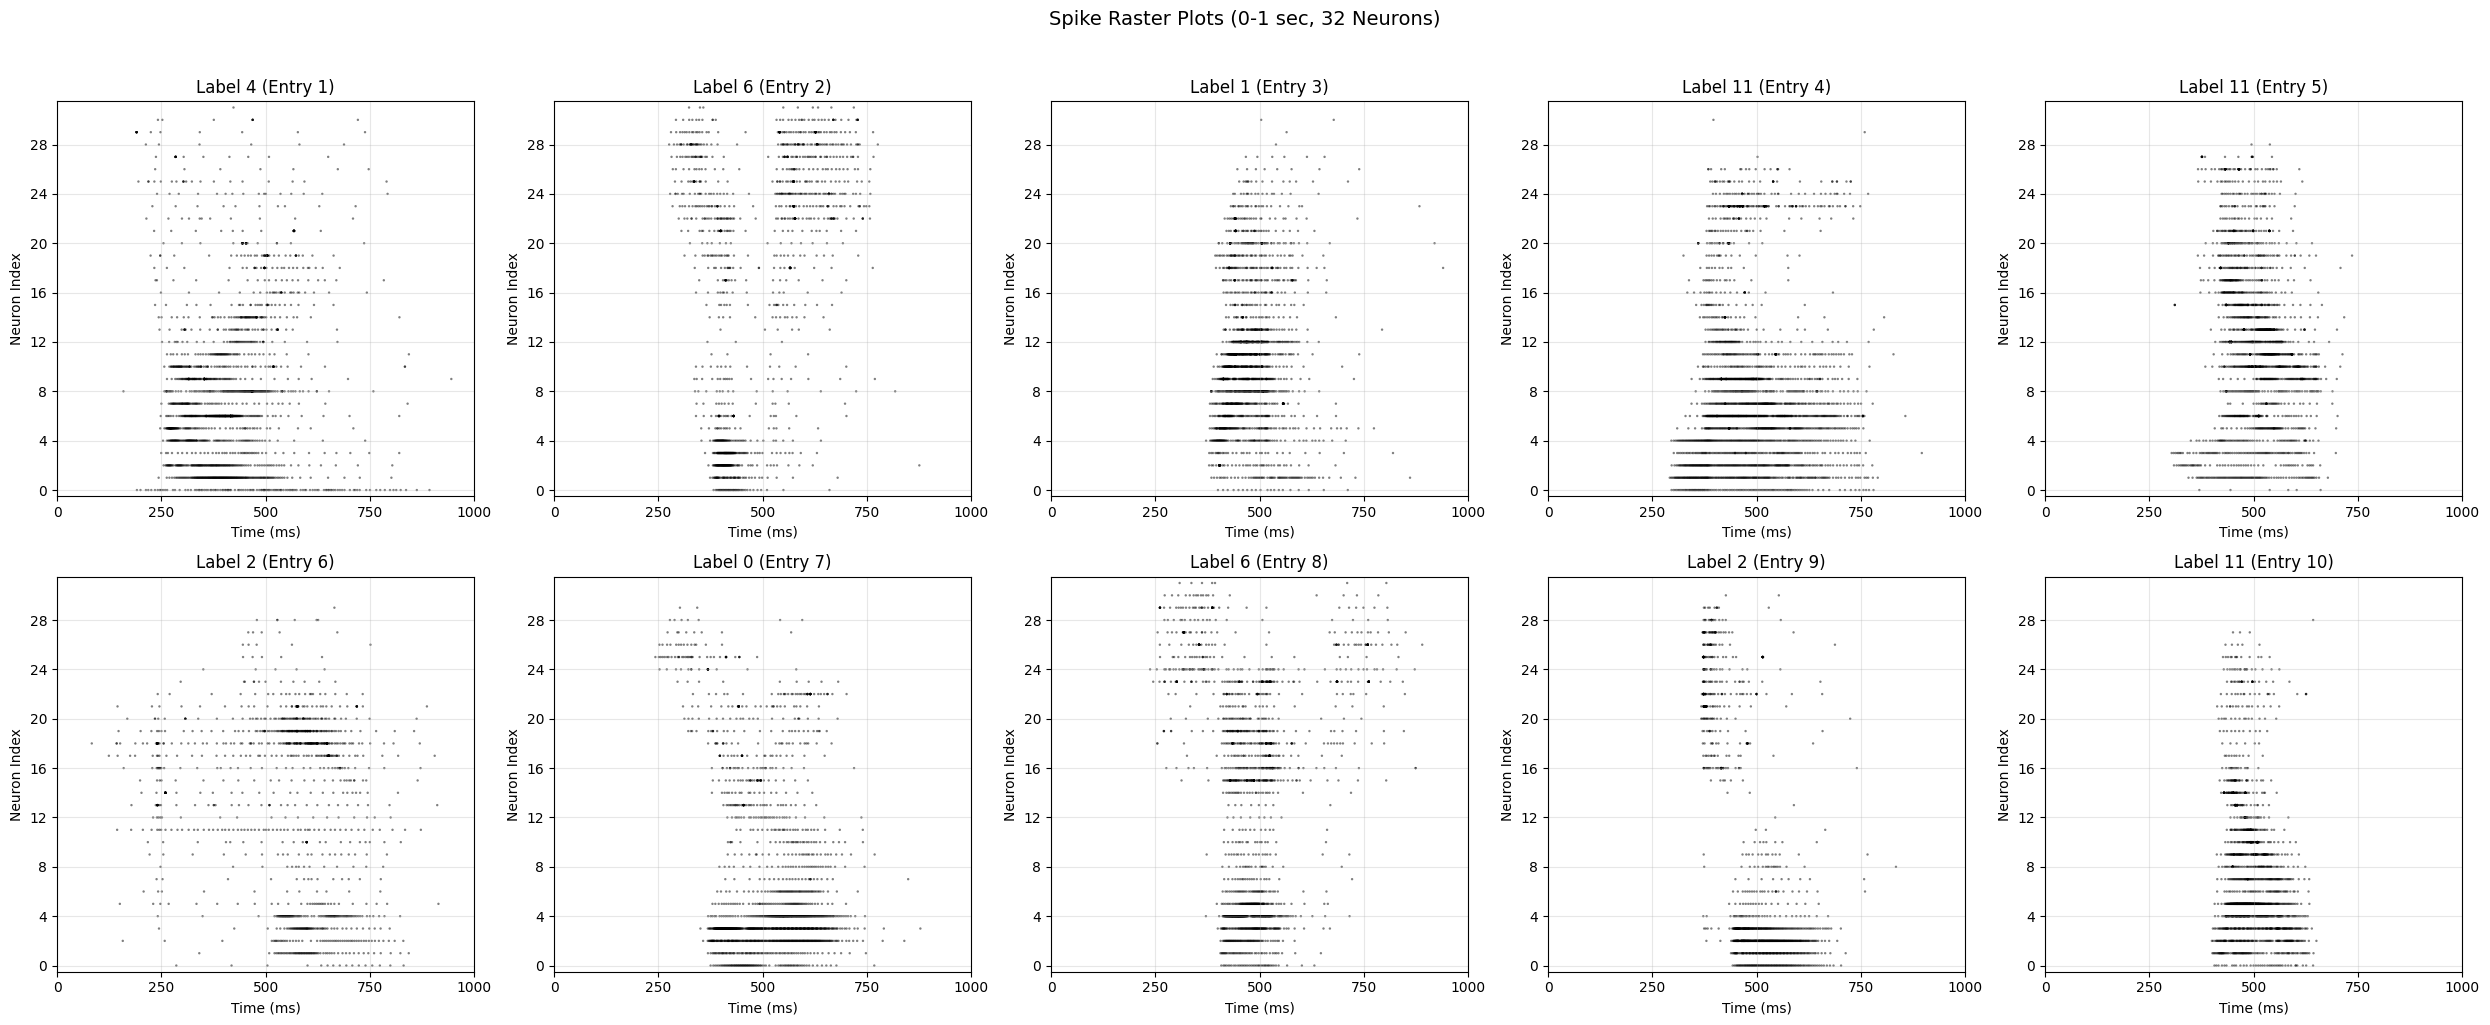

In [20]:
############### 새로만든 후 #############

import struct
import matplotlib.pyplot as plt
import numpy as np

# Define binary format (big-endian)
data_format = [
    ('label', '>B', 1),
    ('data_index', '>H', 2),
    ('unique_global_id', '>I', 4),
    ('num_data_points', '>I', 4),
    ('reserved1', '>B', 1),
    ('reserved2', '>B', 1)
]

spike_format = [
    ('spike_time', '>I', 4),
    ('neuron_index', '>H', 2)
]

def read_entry(file):
    header_data = file.read(13)
    if not header_data:
        return None

    header = {}
    offset = 0
    for name, fmt, size in data_format:
        header[name] = struct.unpack(fmt, header_data[offset:offset+size])[0]
        offset += size

    spikes = []
    for _ in range(header['num_data_points']):
        spike_data = file.read(6)
        if len(spike_data) < 6:
            break
        spike = {
            'spike_time': struct.unpack('>I', spike_data[:4])[0],
            'neuron_index': struct.unpack('>H', spike_data[4:6])[0] & 0x1F  # 5비트 마스킹
        }
        spikes.append(spike)
    return header, spikes

# 파일 경로 설정
file_path = '/home/sungminlee/speakmin/tools/speech-to-spikes/gen_spike/train0.bin'

# 첫 10개 엔트리 로드
entries = []
with open(file_path, 'rb') as f:
    for _ in range(10):
        entry = read_entry(f)
        if entry:
            entries.append(entry)

# 시각화 설정
fig, axes = plt.subplots(2, 5, figsize=(25, 10), dpi=100)
fig.suptitle('Spike Raster Plots (0-1 sec, 32 Neurons)', fontsize=14, y=1.02)

for idx, (header, spikes) in enumerate(entries):
    ax = axes[idx//5, idx%5]
    
    times = [s['spike_time']/1000 for s in spikes]  # μs → ms 변환
    neurons = [s['neuron_index'] for s in spikes]
    
    # 시각화 옵션
    ax.scatter(times, neurons, s=3, alpha=0.5, c='k', edgecolors='none')
    
    # 축 설정
    ax.set_xlim(0, 1000)  # 0-1000 ms
    ax.set_ylim(-0.5, 31.5)
    ax.set_xticks(np.linspace(0, 1000, 5))
    ax.set_yticks(np.arange(0, 32, 4))
    
    ax.set_title(f"Label {header['label']} (Entry {idx+1})")
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Neuron Index')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()